In [1]:
%load_ext dotenv 
%dotenv
%load_ext mypy_ipython
import config
from langgraph.graph import START, END, StateGraph,MessagesState
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, RemoveMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver #You can think of it as the counterpart to the in-memory saver class

cannot find .env file


C:\Users\moham\anaconda3\envs\langgraph_env\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
#Define State
class State(MessagesState):
    summary: str

In [3]:
#Define Nodes
chat = ChatOpenAI(
    model="gpt-3.5-turbo",
    seed= 365,
    temperature=0,
    max_completion_tokens=50,
    openai_api_key = config.api_key
)

In [4]:
def ask_question (state: State) -> State:
    print(f"\n--------> ENTERING ask_question")
    
    question = "What is your question ?"
    print(question)
    return State(messages = [AIMessage(question), HumanMessage(input())])
    

In [5]:
def chatbot (state: State) -> State:
    print(f"\n--------> ENTERING CHATBOT")
    for i in state["messages"]:
        i.pretty_print()

    system_messages = f'''
    Here's a quick summary of what's been discussed so far: {state.get("summary", " ")}
    
    keep this in mind as you answer the next question. 
    '''
    response = chat.invoke( [SystemMessage(system_messages)]+state["messages"])
    response.pretty_print()

    return State(messages = [response])

In [6]:
def summarize_and_delete_msg (state:State) -> State:
    print(f"\n--------> ENTERING trim_messages:")
    
    new_conversation= ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"


    summary_instructions =f'''
    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result reflects the most recent
    context and developments.

    Previous_summary:
    {state.get("summary", "")}

    New_Conversation:
    {new_conversation}
    '''
    print(summary_instructions)
    summary = chat.invoke([HumanMessage(summary_instructions)])
    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]] #Modify the remove messages variable so all messages in the state are deleted.


    return State(messages = remove_messages, summary= summary.content) 

In [7]:
#Define graph
graph = StateGraph(State) ## here pass the schema i.e state class defined above

In [8]:
graph.add_node("ask_question", ask_question)

graph.add_node("chatbot", chatbot)
graph.add_node("summarize_and_delete_msg", summarize_and_delete_msg)

graph.add_edge(START , "ask_question")
graph.add_edge("ask_question" , "chatbot")
graph.add_edge("chatbot" , "summarize_and_delete_msg")
graph.add_edge("summarize_and_delete_msg", END)

In [9]:
db_path ="C:/Users/moham/AI/LANG_GRAPH/LangGraph_db/LangGraph.db"
connection = sqlite3.connect(database = db_path, check_same_thread = False)

In [10]:
checkpointer = SqliteSaver(connection)

In [11]:
graph_compiled = graph.compile(checkpointer)

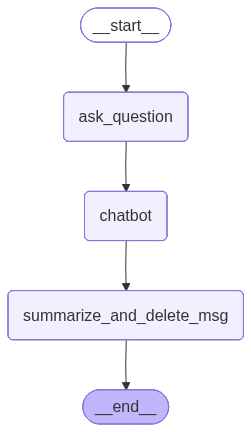

In [12]:
graph_compiled

In [13]:
config1 = {"configurable": {"thread_id": "1"}}

In [14]:
graph_compiled.invoke(State(), config1)


--------> ENTERING ask_question
What is your question ?


 where was he born



--------> ENTERING CHATBOT
================================== Ai Message ==================================

What is your question ?
================================ Human Message =================================

where was he born
================================== Ai Message ==================================

Guido van Rossum, the creator of Python, was born in The Hague, Netherlands.

--------> ENTERING trim_messages:

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result reflects the most recent
    context and developments.

    Previous_summary:
    Previous_summary:
The AI system asked the human for their question, and the human inquired about the creator of Python. The AI responded that Python was created by Guido van Rossum, a Dutch programmer, in the late 1980s.



    New_Conversation:
    ai: What is your question ?

human: where was he born

ai: Guido van Rossu

{'messages': [],
 'summary': "The AI system asked the human for their question, and the human inquired about the creator of Python's birthplace. The AI responded that Guido van Rossum, the creator of Python, was born in The Hague, Netherlands."}

In [16]:
#first run the cell and then restart the cell and ask the similar querstion